# 09 - XAI for Final LightGBM Model

This notebook reconstructs the final LightGBM variant selected in Notebook 08 and performs explainable AI analysis on the frozen test split.

Scope:
- No re-optimization
- No statistical testing
- No changes to preprocessing or selected features
- Publication-ready figure/table exports for manuscript integration

## 1. Setup and Style

In [1]:
import json
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.base import clone
from sklearn.inspection import PartialDependenceDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, QuantileTransformer, RobustScaler, StandardScaler

import sys
sys.path.insert(0, str((Path.cwd() / "..").resolve()))

from utils.plot_config import (
    IEEE_DOUBLE_COL,
    POS_COLOR,
    NEG_COLOR,
    apply_plot_style,
    clean_ax,
)

warnings.filterwarnings("ignore", category=UserWarning)

apply_plot_style()

# Dense rc settings used in archived XAI visuals (kept consistent for SHAP-heavy figures).
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.linewidth": 0.5,
    "lines.linewidth": 0.8,
})

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent

TABLES_DIR = ROOT / "results" / "tables"
FIGURES_DIR = ROOT / "results" / "figures" / "XAI"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Project root: {ROOT}")
print(f"Tables dir  : {TABLES_DIR}")
print(f"Figures dir : {FIGURES_DIR}")

c:\Users\omar8\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01
Tables dir  : c:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables
Figures dir : c:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\figures\XAI


## 2. Load Finalized Artifacts

In [2]:
required_files = [
    TABLES_DIR / "TPE_best_params.csv",
    TABLES_DIR / "GWO_best_params.csv",
    TABLES_DIR / "TPE_test_results.csv",
    TABLES_DIR / "GWO_test_results.csv",
    TABLES_DIR / "selected_features.json",
    TABLES_DIR / "train_test_split_info.json",
    TABLES_DIR / "feature_names.csv",
    TABLES_DIR / "X_train.npy",
    TABLES_DIR / "X_test.npy",
    TABLES_DIR / "y_train.npy",
    TABLES_DIR / "y_test.npy",
]

missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts:\n" + "\n".join(missing))

tpe_best_params_df = pd.read_csv(TABLES_DIR / "TPE_best_params.csv")
gwo_best_params_df = pd.read_csv(TABLES_DIR / "GWO_best_params.csv")
tpe_test_df = pd.read_csv(TABLES_DIR / "TPE_test_results.csv")
gwo_test_df = pd.read_csv(TABLES_DIR / "GWO_test_results.csv")

with open(TABLES_DIR / "selected_features.json", "r", encoding="utf-8") as f:
    selected_features = json.load(f)

with open(TABLES_DIR / "train_test_split_info.json", "r", encoding="utf-8") as f:
    split_info = json.load(f)

feature_names_df = pd.read_csv(TABLES_DIR / "feature_names.csv")
if "feature" not in feature_names_df.columns:
    raise ValueError("feature_names.csv must contain a 'feature' column")

all_feature_names = feature_names_df["feature"].tolist()

X_train_arr = np.load(TABLES_DIR / "X_train.npy")
X_test_arr = np.load(TABLES_DIR / "X_test.npy")
y_train = np.load(TABLES_DIR / "y_train.npy")
y_test = np.load(TABLES_DIR / "y_test.npy")

if X_train_arr.shape[1] != len(all_feature_names):
    raise ValueError(
        f"Feature mismatch: X_train has {X_train_arr.shape[1]} cols but feature_names has {len(all_feature_names)}"
    )

X_train_df = pd.DataFrame(X_train_arr, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_arr, columns=all_feature_names)

missing_selected = sorted(set(selected_features) - set(all_feature_names))
if missing_selected:
    raise ValueError(f"Selected features missing from feature_names.csv: {missing_selected}")

X_train_sel = X_train_df[selected_features].copy()
X_test_sel = X_test_df[selected_features].copy()

print(f"Selected features: {len(selected_features)}")
print(f"Train shape: {X_train_sel.shape}")
print(f"Test shape : {X_test_sel.shape}")
print(f"Split random_state (saved): {split_info.get('random_state', 'N/A')}")

Selected features: 13
Train shape: (48000, 13)
Test shape : (12000, 13)
Split random_state (saved): 42


## 3. Reconstruct Final LightGBM Variant

In [3]:
def sanitize_lgbm_params(raw_row: pd.Series) -> dict:
    int_keys = {
        "n_estimators",
        "num_leaves",
        "max_depth",
        "min_child_samples",
    }
    drop_keys = {"Model", "Optimal_Scaler", "Best_CV_Mean", "Best_Trial", "Best_Iteration"}

    params = {}
    for key, value in raw_row.items():
        if key in drop_keys or pd.isna(value):
            continue
        if key in int_keys:
            params[key] = int(round(float(value)))
        elif isinstance(value, (np.integer, int)):
            params[key] = int(value)
        elif isinstance(value, (np.floating, float)):
            params[key] = float(value)
        else:
            params[key] = value
    return params


def build_scaler(name: str):
    scalers = {
        "Raw": None,
        "Standard": StandardScaler(),
        "MinMax": MinMaxScaler(),
        "Robust": RobustScaler(),
        "Power": PowerTransformer(method="yeo-johnson"),
        "Quantile": QuantileTransformer(output_distribution="uniform", random_state=RANDOM_SEED),
    }
    if name not in scalers:
        raise ValueError(f"Unknown scaler: {name}")
    return scalers[name]


lgbm_tpe = tpe_test_df.loc[tpe_test_df["Model"] == "LGBM"].iloc[0].copy()
lgbm_gwo = gwo_test_df.loc[gwo_test_df["Model"] == "LGBM"].iloc[0].copy()

candidates = pd.DataFrame([
    {"Optimizer": "TPE", **lgbm_tpe.to_dict()},
    {"Optimizer": "GWO", **lgbm_gwo.to_dict()},
])

candidates_sorted = candidates.sort_values(
    by=["Accuracy", "AUC", "LogLoss"],
    ascending=[False, False, True],
).reset_index(drop=True)

selected = candidates_sorted.iloc[0]
selected_optimizer = selected["Optimizer"]
selected_scaler = selected["Optimal_Scaler"]

if selected_optimizer == "TPE":
    lgbm_params_row = tpe_best_params_df.loc[tpe_best_params_df["Model"] == "LGBM"].iloc[0]
else:
    lgbm_params_row = gwo_best_params_df.loc[gwo_best_params_df["Model"] == "LGBM"].iloc[0]

lgbm_params = sanitize_lgbm_params(lgbm_params_row)

lgbm_model = lgb.LGBMClassifier(
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1,
    **lgbm_params,
)

scaler_obj = build_scaler(selected_scaler)
if scaler_obj is None:
    final_pipeline = Pipeline([("model", lgbm_model)])
else:
    final_pipeline = Pipeline([
        ("scaler", clone(scaler_obj)),
        ("model", lgbm_model),
    ])

print("Final LightGBM variant selected from finalized test outputs")
print(candidates_sorted[["Optimizer", "Accuracy", "AUC", "LogLoss"]])
print(f"Selected optimizer: {selected_optimizer}")
print(f"Selected scaler: {selected_scaler}")
print(f"Hyperparameters loaded: {len(lgbm_params)}")

Final LightGBM variant selected from finalized test outputs
  Optimizer  Accuracy       AUC   LogLoss
0       GWO  0.999083  0.999995  0.002970
1       TPE  0.999083  0.999995  0.005067
Selected optimizer: GWO
Selected scaler: Raw
Hyperparameters loaded: 9


In [4]:
final_pipeline.fit(X_train_sel, y_train)

test_pred = final_pipeline.predict(X_test_sel)
test_proba = final_pipeline.predict_proba(X_test_sel)
test_conf = np.max(test_proba, axis=1)

print(f"Test accuracy (reconstructed): {(test_pred == y_test).mean():.6f}")
print(f"Prediction matrix shape: {test_proba.shape}")

if "scaler" in final_pipeline.named_steps:
    X_test_proc = final_pipeline.named_steps["scaler"].transform(X_test_sel)
    X_test_proc_df = pd.DataFrame(X_test_proc, columns=selected_features, index=X_test_sel.index)
else:
    X_test_proc_df = X_test_sel.copy()

model_est = final_pipeline.named_steps["model"]

Test accuracy (reconstructed): 0.999083
Prediction matrix shape: (12000, 2)


## 4. SHAP Computation and Quantitative Summary

In [5]:
explainer = shap.TreeExplainer(model_est)
raw_shap_values = explainer.shap_values(X_test_proc_df)

if isinstance(raw_shap_values, list):
    if len(raw_shap_values) == 2:
        shap_values = raw_shap_values[1]
    else:
        shap_values = raw_shap_values[-1]
else:
    shap_values = raw_shap_values

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.ravel(expected_value)[-1])

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = (
    pd.DataFrame({
        "Feature": selected_features,
        "Mean_Absolute_SHAP": mean_abs_shap,
    })
    .sort_values("Mean_Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)
importance_df["Rank"] = np.arange(1, len(importance_df) + 1)

importance_out = TABLES_DIR / "xai_feature_importance_summary.csv"
importance_df[["Feature", "Mean_Absolute_SHAP", "Rank"]].to_csv(importance_out, index=False)

top6_features = importance_df.head(6)["Feature"].tolist()
feature_to_idx = {f: i for i, f in enumerate(selected_features)}
top6_idx = [feature_to_idx[f] for f in top6_features]

print(f"SHAP matrix shape: {shap_values.shape}")
print(f"Top 6 features: {top6_features}")
print(f"Saved: {importance_out}")
importance_df.head(10)

SHAP matrix shape: (12000, 13)
Top 6 features: ['tau4_g4', 'tau3_g3', 'tau2_g2', 'tau1_g1', 'tau3', 'tau2']
Saved: c:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables\xai_feature_importance_summary.csv


,Feature,Mean_Absolute_SHAP,Rank
0,tau4_g4,6.837216,1
1,tau3_g3,6.824084,2
2,tau2_g2,6.771101,3
3,tau1_g1,5.242012,4
4,tau3,4.269635,5
5,tau2,4.151708,6
6,tau4,4.143781,7
7,g_sum,3.728399,8
8,tau1,3.711498,9
9,tau_mean,3.570563,10


## 5. SHAP Summary Plot (Global Importance)

C:\Users\omar8\AppData\Local\Temp\ipykernel_38944\3648650046.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


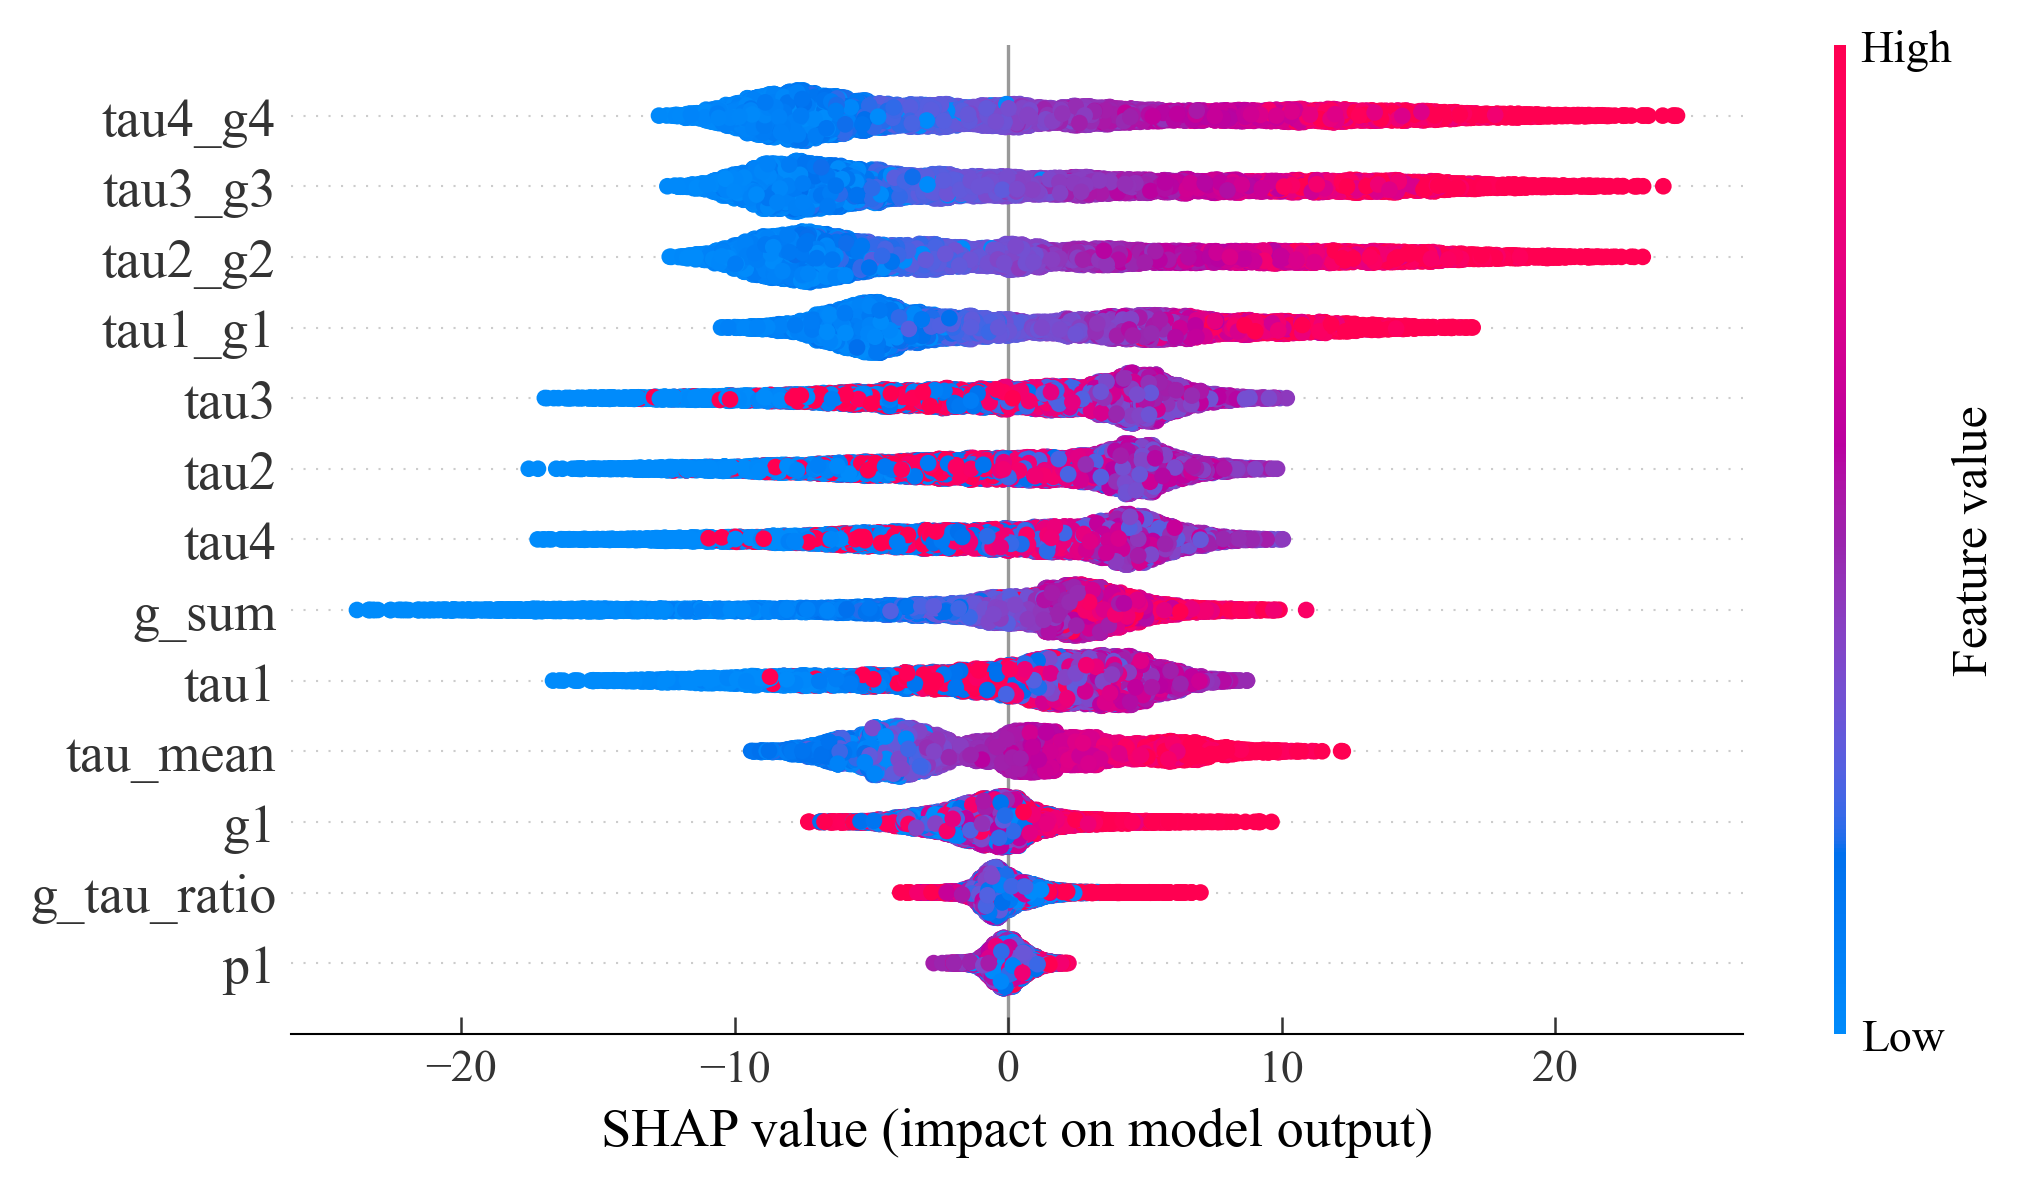

Saved: shap_summary_ieee.(png/pdf)


In [6]:
plt.figure(figsize=(IEEE_DOUBLE_COL, 4.0))
shap.summary_plot(
    shap_values,
    X_test_proc_df,
    show=False,
    color_bar=True,
)
fig = plt.gcf()
fig.set_size_inches(IEEE_DOUBLE_COL, 4.0)
fig.tight_layout()

for ext in ["png", "pdf"]:
    out = FIGURES_DIR / f"shap_summary_ieee.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight")

plt.show()
print("Saved: shap_summary_ieee.(png/pdf)")

## 6. SHAP Dependence Plots (Top 6 Features)

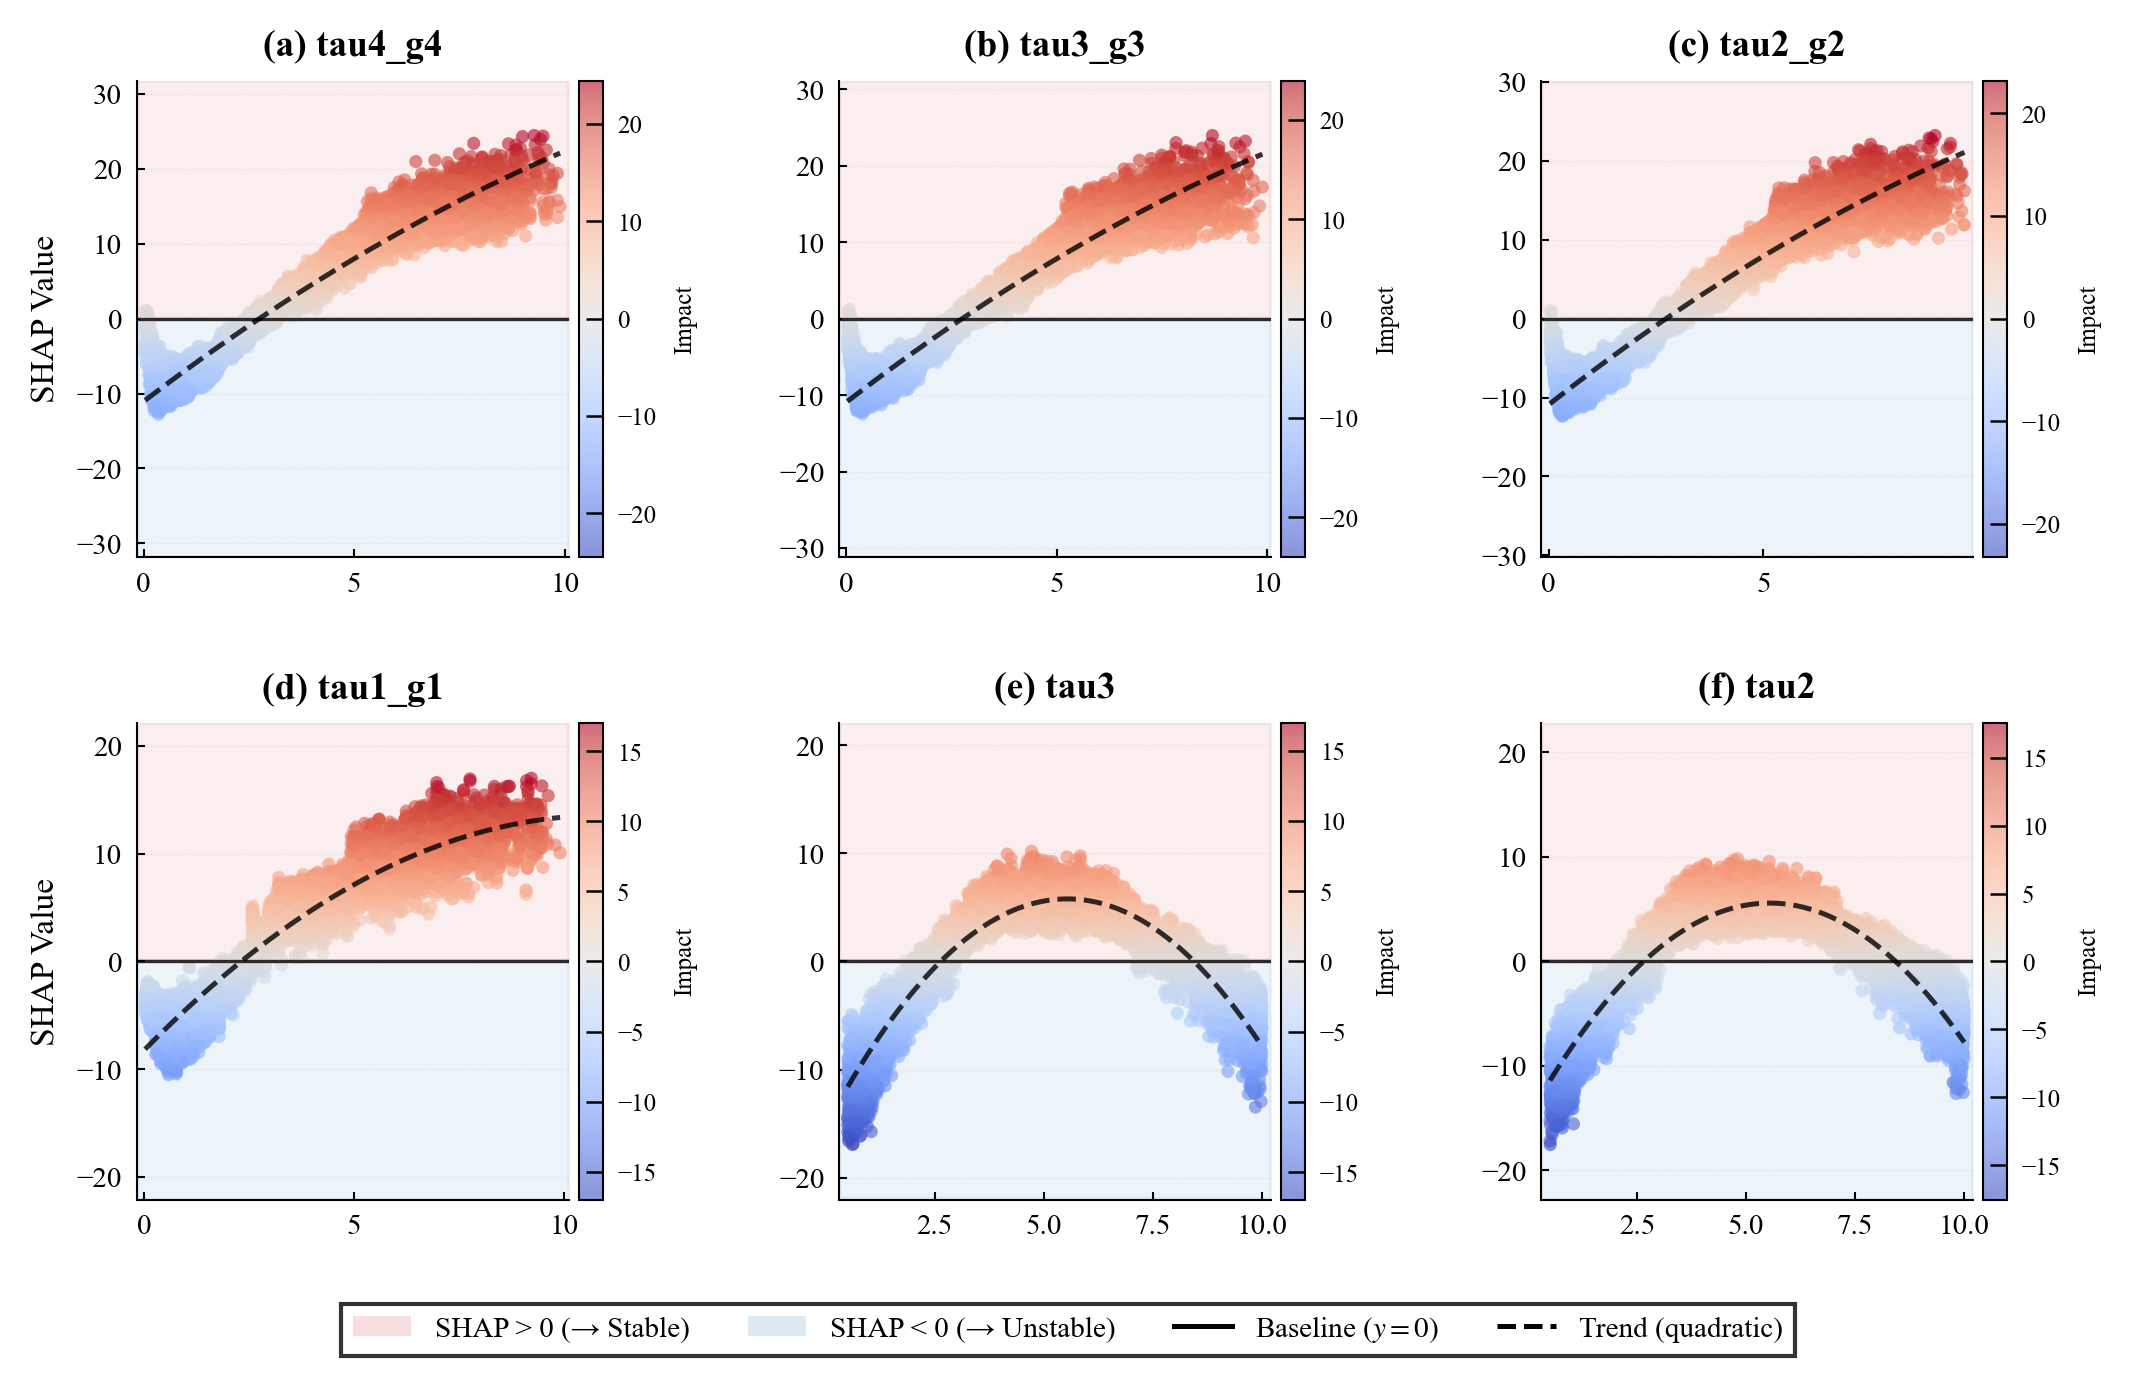

Saved: shap_dependence_top6_ieee.(png/pdf)


In [12]:
from matplotlib.colors import Normalize

fig, axes = plt.subplots(2, 3, figsize=(IEEE_DOUBLE_COL, 4.5))
axes = axes.flatten()

for i, feat in enumerate(top6_features):
    ax = axes[i]
    idx = feature_to_idx[feat]

    shap_feat = shap_values[:, idx]
    feat_values = X_test_proc_df[feat].values

    ylim_max = np.abs(shap_feat).max() * 1.3
    xlim_min = feat_values.min() - 0.2
    xlim_max = feat_values.max() + 0.2

    ax.fill_between([xlim_min, xlim_max], 0, ylim_max, alpha=0.08, color=POS_COLOR, zorder=0)
    ax.fill_between([xlim_min, xlim_max], -ylim_max, 0, alpha=0.08, color=NEG_COLOR, zorder=0)

    norm = Normalize(vmin=-np.abs(shap_feat).max(), vmax=np.abs(shap_feat).max())
    scatter = ax.scatter(
        feat_values,
        shap_feat,
        c=shap_feat,
        cmap="coolwarm",
        norm=norm,
        alpha=0.60,
        s=10,
        edgecolors="none",
    )

    if len(np.unique(feat_values)) > 2:
        z = np.polyfit(feat_values, shap_feat, deg=2)
        xp = np.linspace(feat_values.min(), feat_values.max(), 100)
        yp = np.poly1d(z)(xp)
        ax.plot(xp, yp, linestyle="--", linewidth=1.2, color="black", alpha=0.8)

    ax.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.8)
    ax.set_title(f"({chr(97+i)}) {feat}", fontsize=9, fontweight="bold", pad=6)

    if i % 3 == 0:
        ax.set_ylabel("SHAP Value", fontsize=8)
    else:
        ax.set_ylabel("")

    ax.set_xlabel("")
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(-ylim_max, ylim_max)

    cbar = plt.colorbar(scatter, ax=ax, pad=0.02, aspect=20)
    cbar.set_label("Impact", fontsize=6)
    cbar.ax.tick_params(labelsize=6)

    clean_ax(ax, left_label=(i % 3 == 0))
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(axis="both", which="major", length=2, width=0.5)

legend_elements = [
    Patch(facecolor=POS_COLOR, alpha=0.15, label="SHAP > 0 (→ Stable)"),
    Patch(facecolor=NEG_COLOR, alpha=0.15, label="SHAP < 0 (→ Unstable)"),
    Line2D([0], [0], color="black", linestyle="-", linewidth=1.2, label="Baseline ($y=0$)"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.2, label="Trend (quadratic)"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    fontsize=7,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
    edgecolor="black",
    fancybox=False,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(hspace=0.35, wspace=0.35)

for ext in ["png", "pdf"]:
    out = FIGURES_DIR / f"shap_dependence_top6_ieee.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")

plt.show()
print("Saved: shap_dependence_top6_ieee.(png/pdf)")

## 7. SHAP Waterfall Bridge (Stable and Unstable Cases)

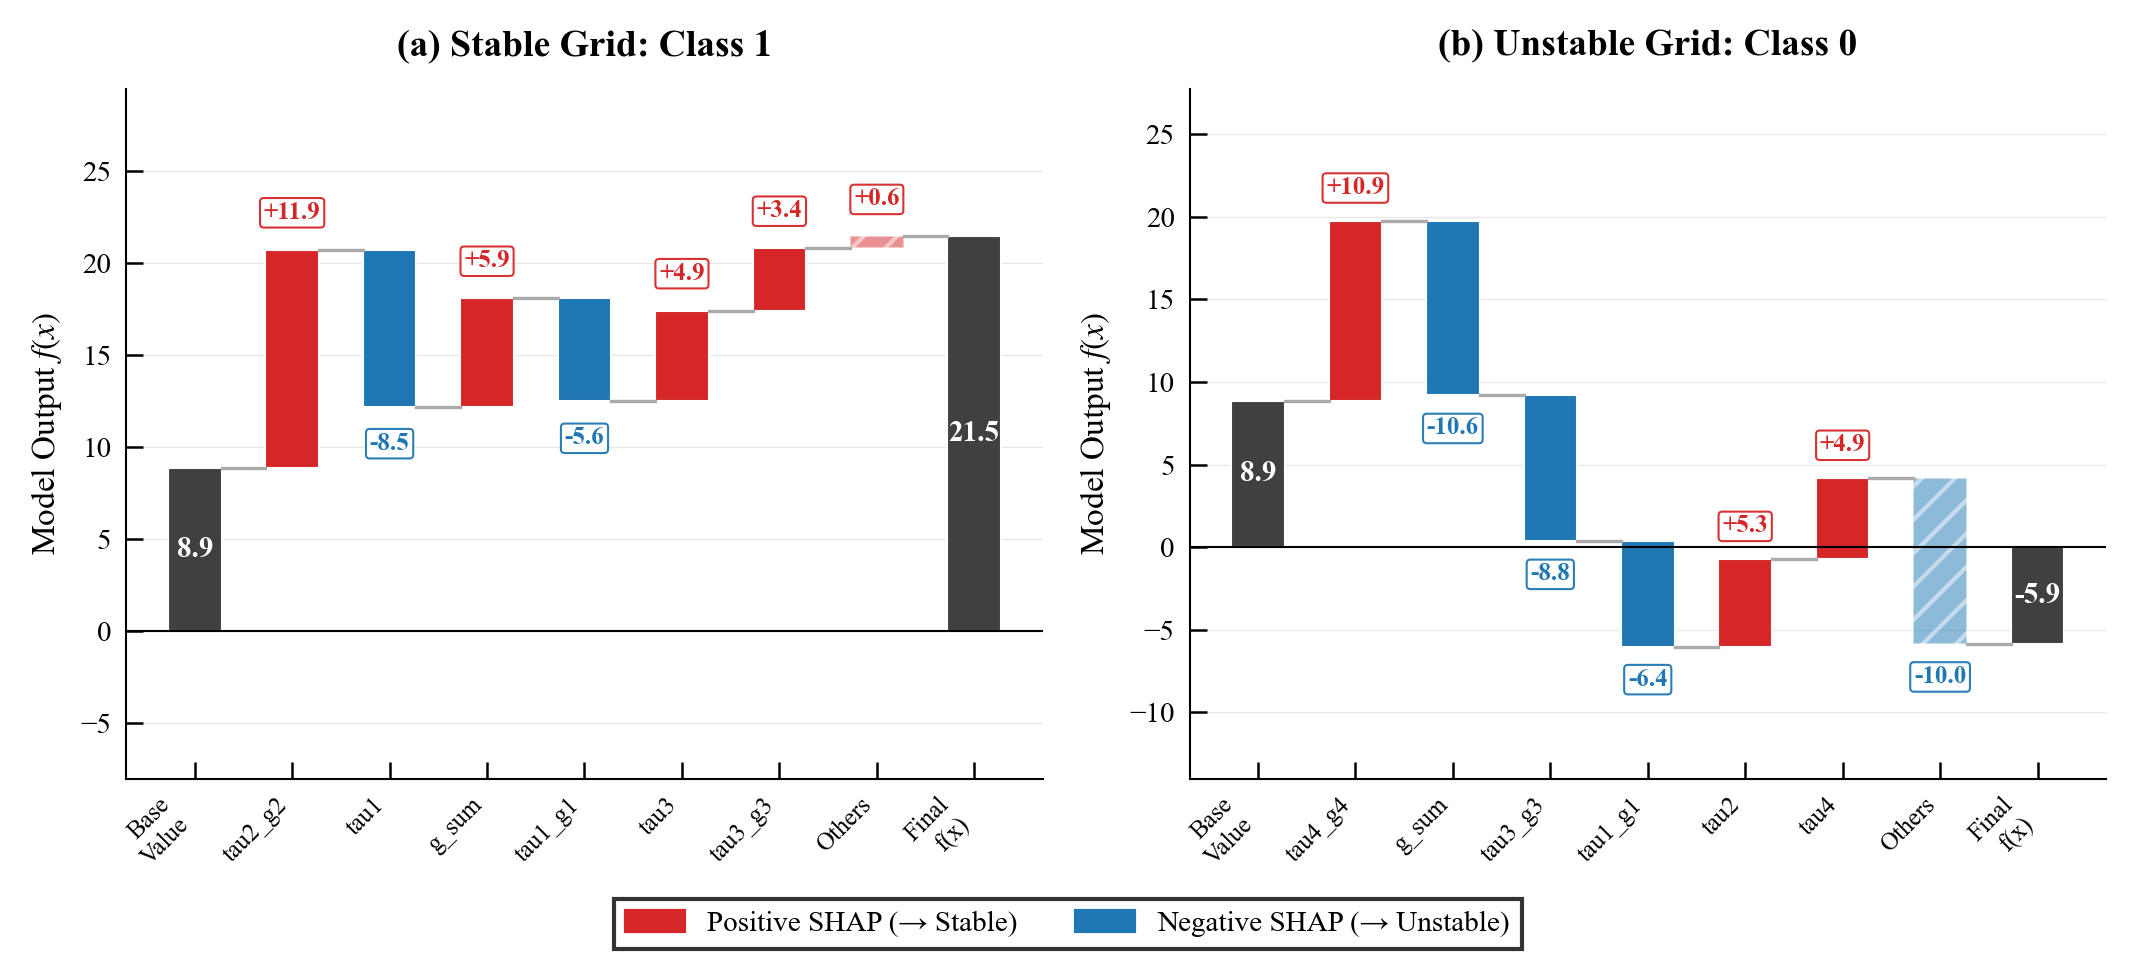

Saved: shap_waterfall_bridge.(png/pdf)


In [13]:
import matplotlib.patches as mpatches

label_map = {1: "Stable", 0: "Unstable"}

def create_waterfall_ieee(shap_vals, feature_names, base_value, ax, title, prediction_label, confidence, top_n=6):
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1]
    top_idx = sorted_idx[:top_n]
    other_idx = sorted_idx[top_n:]

    shap_top = shap_vals[top_idx]
    features_top = [feature_names[i] for i in top_idx]
    shap_others = np.sum(shap_vals[other_idx]) if len(other_idx) > 0 else 0
    final_value = base_value + np.sum(shap_vals)

    red = POS_COLOR
    blue = NEG_COLOR
    gray = "#404040"
    connector = "#AAAAAA"

    bar_width = 0.55
    include_others = len(other_idx) > 0 and abs(shap_others) > 0.01
    n_bars = top_n + 2 + (1 if include_others else 0)
    x_positions = np.arange(n_bars)

    labels = ["Base\nValue"] + features_top
    if include_others:
        labels.append("Others")
    labels.append("Final\nf(x)")

    cumulative = base_value
    y_values = [base_value]

    ax.bar(0, base_value, bar_width, bottom=0, color=gray, edgecolor="white", linewidth=0.5)
    ax.text(0, base_value / 2, f"{base_value:.1f}", ha="center", va="center", fontsize=7, fontweight="bold", color="white")
    ax.plot([bar_width / 2, 1 - bar_width / 2], [base_value, base_value], color=connector, linestyle="-", linewidth=0.8)

    for i, shap_val in enumerate(shap_top):
        x = i + 1

        if shap_val >= 0:
            bottom = cumulative
            height = shap_val
            color = red
            ann_y = cumulative + shap_val + 2
            ann_text = f"+{shap_val:.1f}"
        else:
            bottom = cumulative + shap_val
            height = abs(shap_val)
            color = blue
            ann_y = bottom - 2
            ann_text = f"{shap_val:.1f}"

        ax.bar(x, height, bar_width, bottom=bottom, color=color, edgecolor="white", linewidth=0.5)
        ax.text(
            x,
            ann_y,
            ann_text,
            ha="center",
            va="center",
            fontsize=6,
            fontweight="bold",
            color=color,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor=color, linewidth=0.5, alpha=0.95),
        )

        cumulative += shap_val
        y_values.append(cumulative)

        next_x = x + 1
        ax.plot([x + bar_width / 2, next_x - bar_width / 2], [cumulative, cumulative], color=connector, linestyle="-", linewidth=0.8)

    if include_others:
        x = top_n + 1
        if shap_others >= 0:
            bottom, height, color = cumulative, shap_others, red
            ann_y, ann_text = cumulative + shap_others + 2, f"+{shap_others:.1f}"
        else:
            bottom, height, color = cumulative + shap_others, abs(shap_others), blue
            ann_y, ann_text = bottom - 2, f"{shap_others:.1f}"

        ax.bar(x, height, bar_width, bottom=bottom, color=color, edgecolor="white", linewidth=0.5, alpha=0.5, hatch="///")
        ax.text(
            x,
            ann_y,
            ann_text,
            ha="center",
            va="center",
            fontsize=6,
            fontweight="bold",
            color=color,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor=color, linewidth=0.5, alpha=0.95),
        )

        cumulative += shap_others
        y_values.append(cumulative)
        ax.plot([x + bar_width / 2, x + 1 - bar_width / 2], [cumulative, cumulative], color=connector, linestyle="-", linewidth=0.8)

    final_x = top_n + 1 + (1 if include_others else 0)
    y_values.append(final_value)

    if final_value >= 0:
        ax.bar(final_x, final_value, bar_width, bottom=0, color=gray, edgecolor="white", linewidth=0.5)
        ax.text(final_x, final_value / 2, f"{final_value:.1f}", ha="center", va="center", fontsize=7, fontweight="bold", color="white")
    else:
        ax.bar(final_x, abs(final_value), bar_width, bottom=final_value, color=gray, edgecolor="white", linewidth=0.5)
        ax.text(final_x, final_value / 2, f"{final_value:.1f}", ha="center", va="center", fontsize=7, fontweight="bold", color="white")

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
    ax.set_ylabel("Model Output $f(x)$", fontsize=8)
    ax.set_title(f"{title}: {prediction_label}", fontsize=9, fontweight="bold", pad=8)

    y_min = min(y_values + [0]) - 8
    y_max = max(y_values) + 8
    ax.set_ylim(y_min, y_max)

    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax.yaxis.grid(True, alpha=0.3, linestyle="-", linewidth=0.3)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)

def calculate_balance_score(shap_vals):
    pos_sum = np.sum(shap_vals[shap_vals > 0])
    neg_sum = np.abs(np.sum(shap_vals[shap_vals < 0]))
    if pos_sum == 0 or neg_sum == 0:
        return 0
    return min(pos_sum, neg_sum) / max(pos_sum, neg_sum)

stable_mask = (y_test == 1) & (test_pred == 1)
unstable_mask = (y_test == 0) & (test_pred == 0)

stable_indices = np.where(stable_mask)[0]
unstable_indices = np.where(unstable_mask)[0]

stable_balance_scores = [calculate_balance_score(shap_values[i]) for i in stable_indices]
unstable_balance_scores = [calculate_balance_score(shap_values[i]) for i in unstable_indices]

stable_candidates = [
    (idx, score, test_proba[idx, 1])
    for idx, score in zip(stable_indices, stable_balance_scores)
    if 0.05 <= score <= 0.6 and test_proba[idx, 1] > 0.7
]
unstable_candidates = [
    (idx, score, test_proba[idx, 0])
    for idx, score in zip(unstable_indices, unstable_balance_scores)
    if 0.05 <= score <= 0.6 and test_proba[idx, 0] > 0.7
]

stable_candidates.sort(key=lambda x: x[1], reverse=True)
unstable_candidates.sort(key=lambda x: x[1], reverse=True)

stable_idx = stable_candidates[0][0] if stable_candidates else stable_indices[np.argmax(test_proba[stable_indices, 1])]
unstable_idx = unstable_candidates[0][0] if unstable_candidates else unstable_indices[np.argmax(test_proba[unstable_indices, 0])]

base_value = expected_value

fig, axes = plt.subplots(1, 2, figsize=(IEEE_DOUBLE_COL, 3.2))

create_waterfall_ieee(
    shap_vals=shap_values[stable_idx],
    feature_names=selected_features,
    base_value=base_value,
    ax=axes[0],
    title="(a) Stable Grid",
    prediction_label="Class 1",
    confidence=test_proba[stable_idx, 1],
    top_n=6,
)

create_waterfall_ieee(
    shap_vals=shap_values[unstable_idx],
    feature_names=selected_features,
    base_value=base_value,
    ax=axes[1],
    title="(b) Unstable Grid",
    prediction_label="Class 0",
    confidence=test_proba[unstable_idx, 0],
    top_n=6,
)

red_patch = mpatches.Patch(color=POS_COLOR, label="Positive SHAP (→ Stable)")
blue_patch = mpatches.Patch(color=NEG_COLOR, label="Negative SHAP (→ Unstable)")
fig.legend(
    handles=[red_patch, blue_patch],
    loc="lower center",
    ncol=2,
    fontsize=7,
    frameon=True,
    bbox_to_anchor=(0.5, -0.01),
    edgecolor="black",
    fancybox=False,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

for ext in ["png", "pdf"]:
    out = FIGURES_DIR / f"shap_waterfall_bridge.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")

plt.show()
print("Saved: shap_waterfall_bridge.(png/pdf)")

## 8. ICE + PDP for Key Features

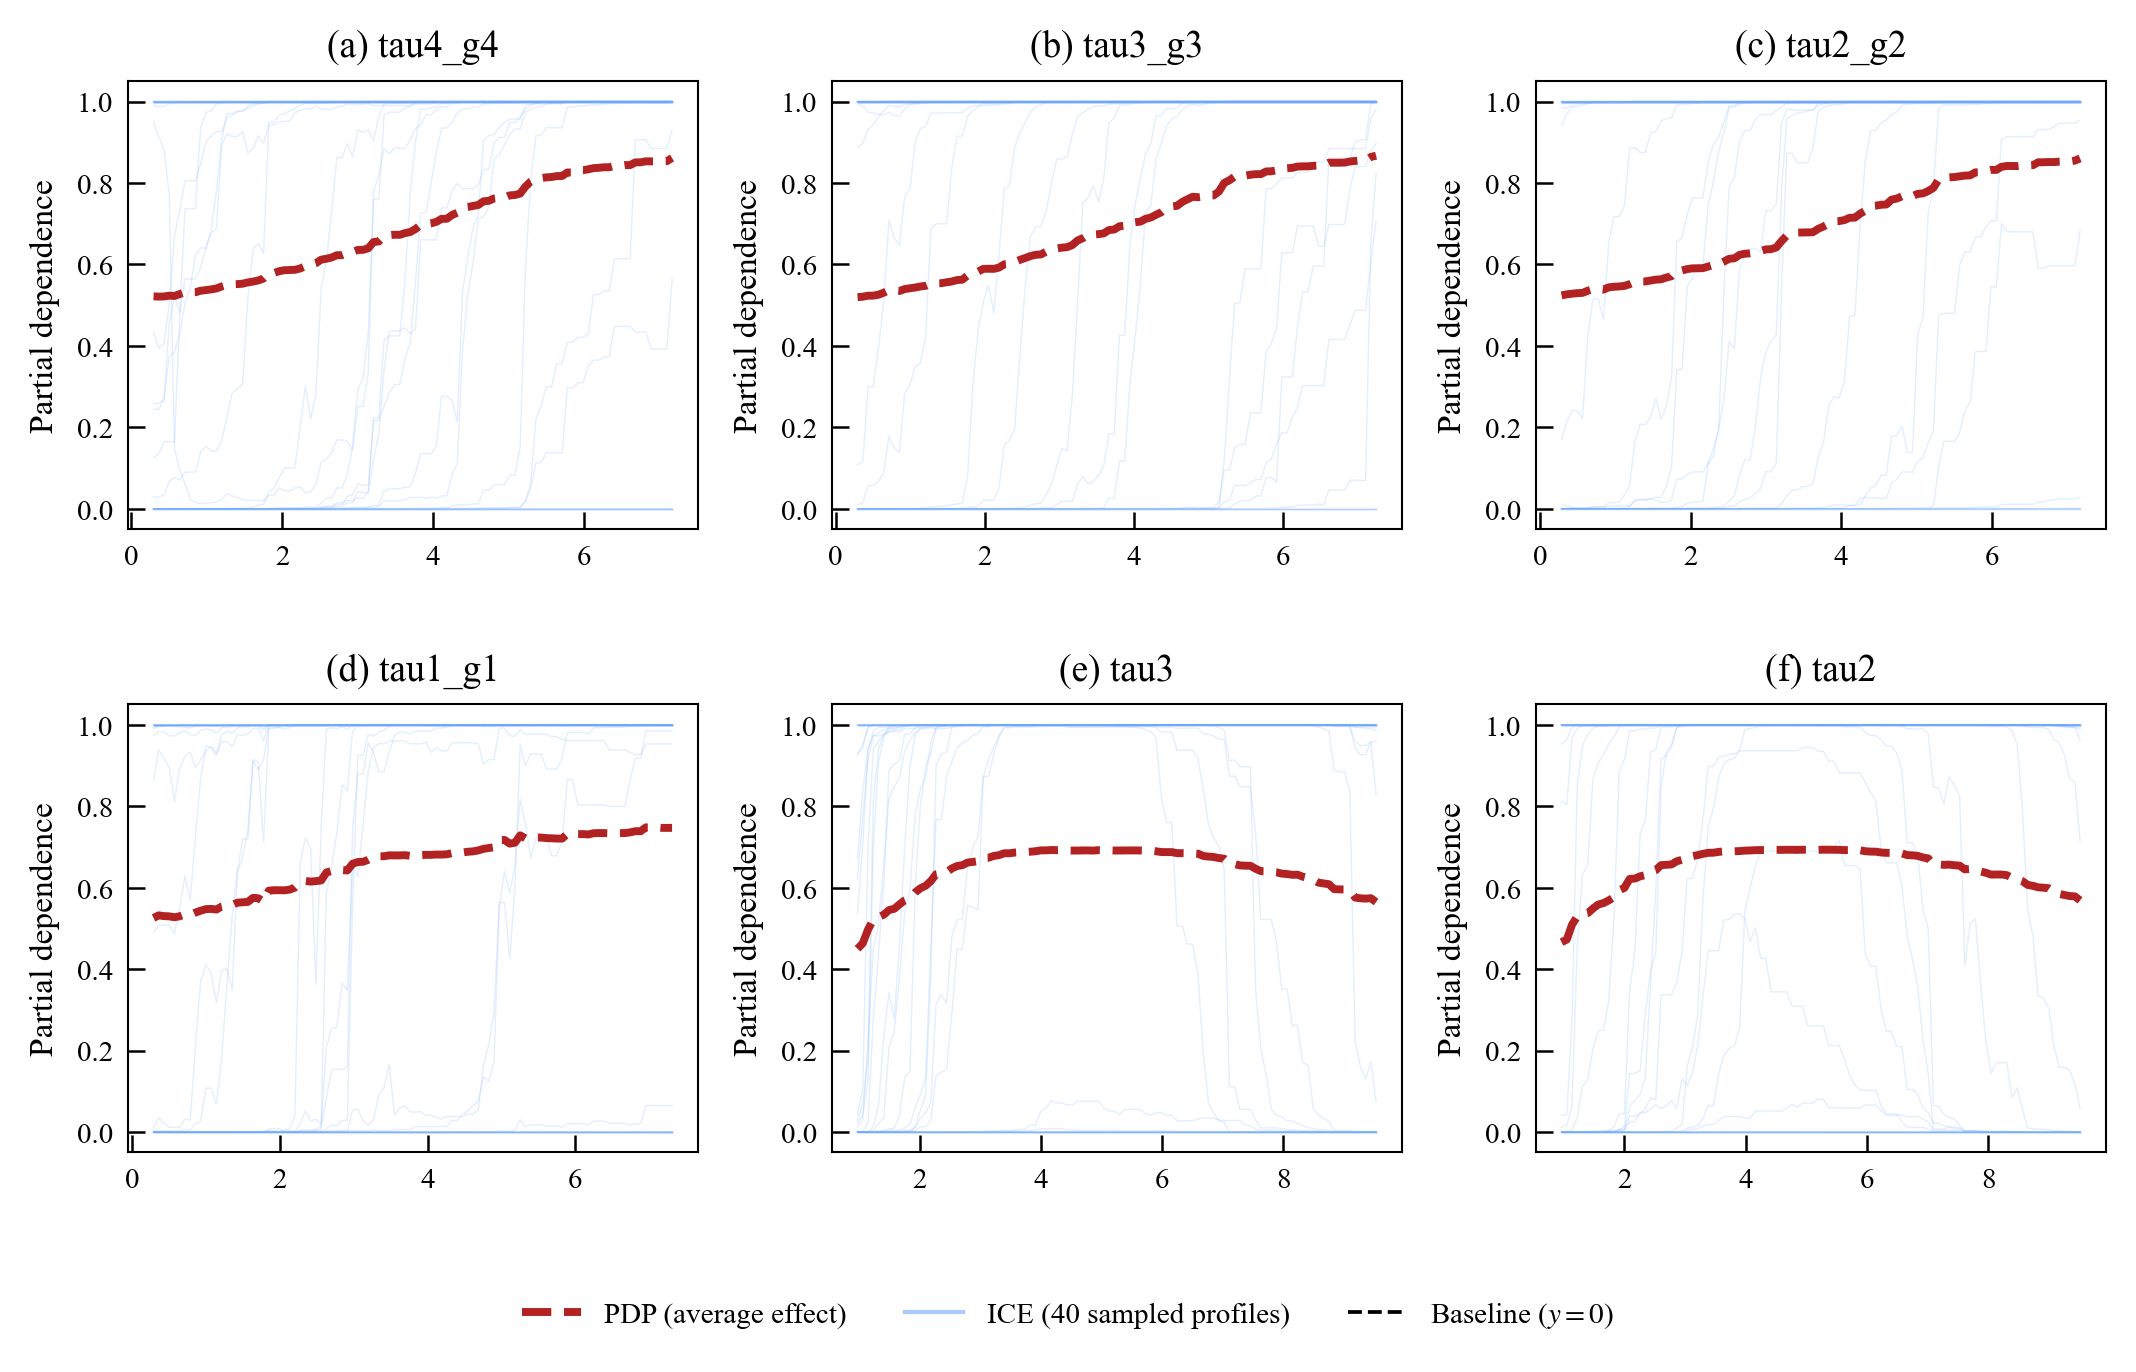

Saved: ice_pdp_key_features.(png/pdf)


In [21]:
from matplotlib.lines import Line2D

placeholder_names = [" " * (i + 1) for i in range(len(selected_features))]

fig, axes = plt.subplots(2, 3, figsize=(IEEE_DOUBLE_COL, 4.5))
axes = axes.flatten()

for i, feat in enumerate(top6_features):
    ax = axes[i]
    feat_idx = feature_to_idx[feat]

    display = PartialDependenceDisplay.from_estimator(
        final_pipeline,
        X_test_sel,
        features=[feat_idx],
        feature_names=placeholder_names,
        kind="both",
        subsample=40,
        random_state=RANDOM_SEED,
        ice_lines_kw={"color": "#6EA8FE", "alpha": 0.18, "linewidth": 0.35},
        pd_line_kw={"color": "#B22222", "linewidth": 1.9, "linestyle": "--"},
        ax=ax,
    )

    if hasattr(display, "deciles_vlines_"):
        for artist in np.ravel(display.deciles_vlines_):
            if artist is not None:
                artist.set_visible(False)

    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_title(f"({chr(97+i)}) {feat}", pad=6)
    ax.set_xlabel("")
    ax.xaxis.label.set_visible(False)
    if i % 3 == 0:
        ax.set_ylabel("Partial dependence")
    else:
        ax.set_ylabel("")

    ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
    clean_ax(ax, left_label=(i % 3 == 0))
    ax.tick_params(axis="x", pad=2)

for subplot_ax in fig.axes:
    if subplot_ax.legend_ is not None:
        subplot_ax.legend_.remove()

legend_handles = [
    Line2D([0], [0], color="#B22222", linewidth=1.9, linestyle="--", label="PDP (average effect)"),
    Line2D([0], [0], color="#6EA8FE", linewidth=1.0, alpha=0.6, label="ICE (40 sampled profiles)"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=0.9, label="Baseline ($y=0$)"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)
fig.subplots_adjust(hspace=0.35, wspace=0.25)
fig.tight_layout(rect=[0, 0.05, 1, 1])

for ext in ["png", "pdf"]:
    out = FIGURES_DIR / f"ice_pdp_key_features.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight")

plt.show()
print("Saved: ice_pdp_key_features.(png/pdf)")

## 9. Local Explanation Summary Table (Two Representative Cases)

In [14]:
def top_signed_features(sample_shap: np.ndarray, top_k: int = 3):
    pos_idx = np.argsort(sample_shap)[::-1]
    neg_idx = np.argsort(sample_shap)

    pos = [f"{selected_features[i]} ({sample_shap[i]:+.3f})" for i in pos_idx[:top_k] if sample_shap[i] > 0]
    neg = [f"{selected_features[i]} ({sample_shap[i]:+.3f})" for i in neg_idx[:top_k] if sample_shap[i] < 0]

    return "; ".join(pos) if pos else "None", "; ".join(neg) if neg else "None"


rows = []
for case_idx in [stable_idx, unstable_idx]:
    pos_txt, neg_txt = top_signed_features(shap_values[case_idx], top_k=3)
    rows.append({
        "Case_ID": int(case_idx),
        "True_Label": label_map.get(int(y_test[case_idx]), str(y_test[case_idx])),
        "Predicted_Label": label_map.get(int(test_pred[case_idx]), str(test_pred[case_idx])),
        "Probability": float(test_proba[case_idx, int(test_pred[case_idx])]),
        "Top_Positive_Features": pos_txt,
        "Top_Negative_Features": neg_txt,
    })

local_case_df = pd.DataFrame(rows)
local_out = TABLES_DIR / "xai_local_case_summary.csv"
local_case_df.to_csv(local_out, index=False)

print(f"Saved: {local_out}")
local_case_df

Saved: c:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables\xai_local_case_summary.csv


,Case_ID,True_Label,Predicted_Label,Probability,Top_Positive_Features,Top_Negative_Features
0,8467,Stable,Stable,1.000000,tau2_g2 (+11.876); g_sum (+5.911); tau3 (+4.941),tau1 (-8.543); tau1_g1 (-5.618); g1 (-2.538)
1,5256,Unstable,Unstable,0.997165,tau4_g4 (+10.885); tau2 (+5.283); tau4 (+4.912),g_sum (-10.563); tau3_g3 (-8.835); tau1_g1 (-6...


## 10. Export Verification

In [15]:
expected_figures = [
    "shap_summary_ieee.png",
    "shap_summary_ieee.pdf",
    "shap_dependence_top6_ieee.png",
    "shap_dependence_top6_ieee.pdf",
    "shap_waterfall_bridge.png",
    "shap_waterfall_bridge.pdf",
    "ice_pdp_key_features.png",
    "ice_pdp_key_features.pdf",
]

expected_tables = [
    TABLES_DIR / "xai_feature_importance_summary.csv",
    TABLES_DIR / "xai_local_case_summary.csv",
]

missing_figs = [f for f in expected_figures if not (FIGURES_DIR / f).exists()]
missing_tabs = [str(t) for t in expected_tables if not t.exists()]

print("Figure directory contents:")
for p in sorted(FIGURES_DIR.glob("*")):
    print(f" - {p.name}")

if missing_figs or missing_tabs:
    print("\nMissing outputs detected:")
    if missing_figs:
        print("Figures:", missing_figs)
    if missing_tabs:
        print("Tables:", missing_tabs)
else:
    print("\nAll required figures and tables are present.")

Figure directory contents:
 - ice_pdp_key_features.pdf
 - ice_pdp_key_features.png
 - shap_dependence_top6_ieee.pdf
 - shap_dependence_top6_ieee.png
 - shap_summary_ieee.pdf
 - shap_summary_ieee.png
 - shap_waterfall_bridge.pdf
 - shap_waterfall_bridge.png

All required figures and tables are present.
